# 07 Multivariate Analysis

## Objective

Objective:
Perform multivariate analysis to understand how multiple features interact with each other and with the target variable `Churn`.

This step helps in:
- Identifying feature combinations that are strongly associated with churn
- Detecting redundancy and multicollinearity among predictors
- Finding interaction patterns that may support feature engineering
- Translating bivariate findings into modeling-oriented insights


## Imports


In [19]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS, TARGET_COLUMN
from src.data.data_loader import load_cleaned_data

sns.set_theme(style="whitegrid")


## Report Paths

Store multivariate analysis outputs in dedicated report folders so figures and tables stay organized.


In [20]:
REPORTS_DIR = project_root / "reports"
MULTIVARIATE_FIGURES_DIR = REPORTS_DIR / "figures" / "multivariate"
MULTIVARIATE_TABLES_DIR = REPORTS_DIR / "tables" / "multivariate"
NUMERICAL_RELATIONSHIPS_FIGURES_DIR = MULTIVARIATE_FIGURES_DIR / "numerical_relationships"
NUMERICAL_RELATIONSHIPS_TABLES_DIR = MULTIVARIATE_TABLES_DIR / "numerical_relationships"
CATEGORICAL_INTERACTIONS_FIGURES_DIR = MULTIVARIATE_FIGURES_DIR / "categorical_interactions"
CATEGORICAL_INTERACTIONS_TABLES_DIR = MULTIVARIATE_TABLES_DIR / "categorical_interactions"
MIXED_INTERACTIONS_FIGURES_DIR = MULTIVARIATE_FIGURES_DIR / "mixed_interactions"
MIXED_INTERACTIONS_TABLES_DIR = MULTIVARIATE_TABLES_DIR / "mixed_interactions"

for path in [
    NUMERICAL_RELATIONSHIPS_FIGURES_DIR,
    NUMERICAL_RELATIONSHIPS_TABLES_DIR,
    CATEGORICAL_INTERACTIONS_FIGURES_DIR,
    CATEGORICAL_INTERACTIONS_TABLES_DIR,
    MIXED_INTERACTIONS_FIGURES_DIR,
    MIXED_INTERACTIONS_TABLES_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

{
    "multivariate_figures": MULTIVARIATE_FIGURES_DIR,
    "multivariate_tables": MULTIVARIATE_TABLES_DIR,
}


{'multivariate_figures': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/figures/multivariate'),
 'multivariate_tables': PosixPath('/Users/mohammadmubashir/VCode/Churn/reports/tables/multivariate')}

## Load Data and Separate Feature Types

Load the cleaned dataset and keep the same target, numerical, and categorical feature groups used in earlier notebooks.


In [21]:
df = load_cleaned_data()

target_column = TARGET_COLUMN
numerical_columns = [column for column in NUMERICAL_COLUMNS if column in df.columns]
categorical_columns = [column for column in CATEGORICAL_COLUMNS if column in df.columns]

feature_groups = {
    "target_column": target_column,
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
}

feature_groups


{'target_column': 'Churn',
 'numerical_columns': ['tenure', 'MonthlyCharges', 'TotalCharges'],
 'categorical_columns': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod']}

## Correlation Analysis for Numerical Features

Start with the numerical features to see which variables move together, where redundancy may exist, and whether any pair is strong enough to matter later in feature engineering.


,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


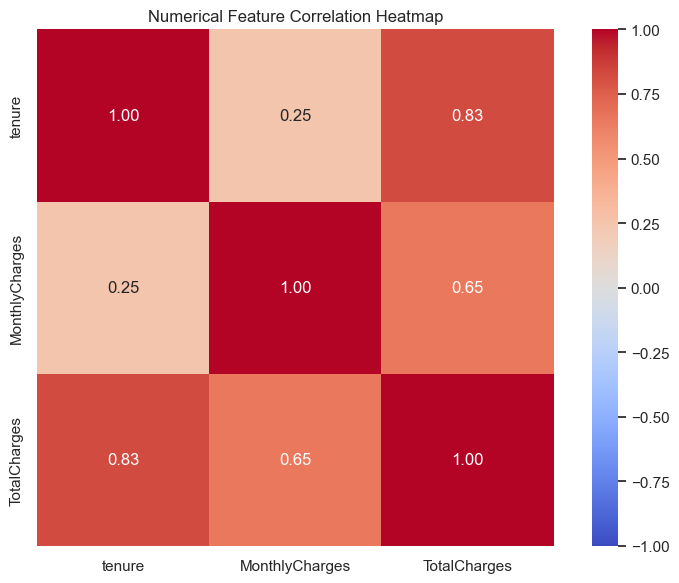

In [22]:
numerical_correlation = df[numerical_columns].corr().round(3)
numerical_correlation.to_csv(
    NUMERICAL_RELATIONSHIPS_TABLES_DIR / "numerical_correlation_matrix.csv"
)

display(numerical_correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(
    numerical_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(
    NUMERICAL_RELATIONSHIPS_FIGURES_DIR / "numerical_correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


The correlation matrix confirms that `tenure` and `TotalCharges` are strongly related with a correlation of `0.826`, which means both variables are capturing the same customer-lifecycle pattern to a large extent. `MonthlyCharges` has a moderate correlation with `TotalCharges` (`0.651`) and only a weak correlation with `tenure` (`0.248`), so price contributes information beyond tenure, but far less strongly than lifetime length does.


## Scatter Plots for Numerical Relationships Colored by Target

Use scatter plots to see whether churn classes separate more clearly when numerical features are viewed together instead of one at a time.


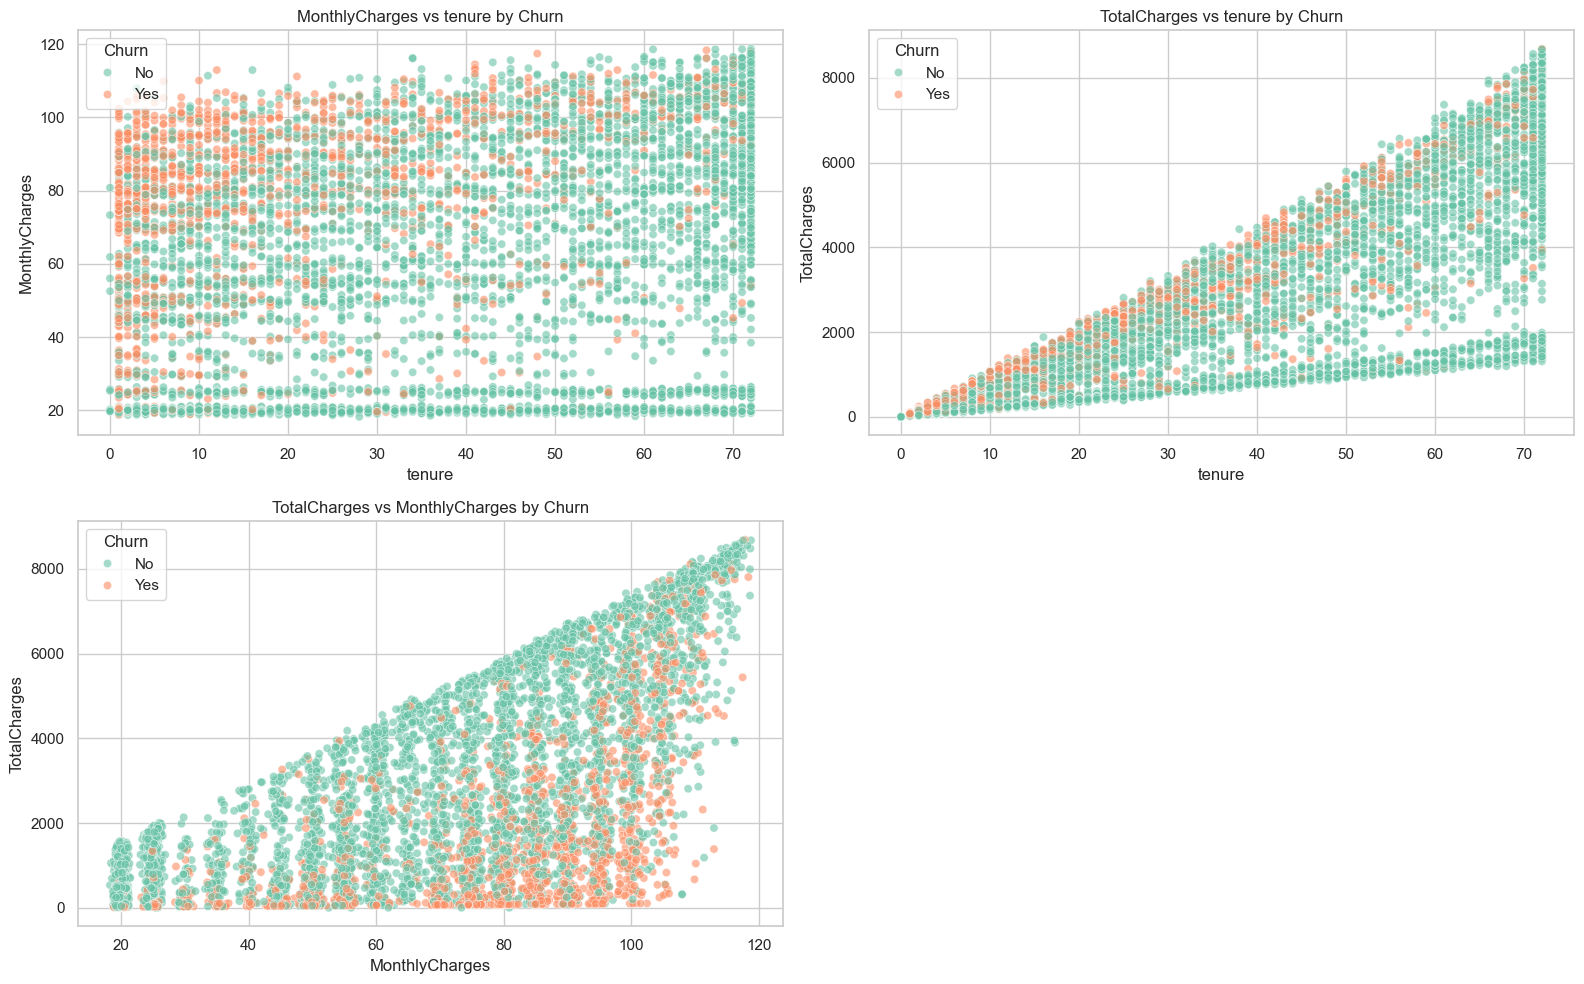

In [11]:
numerical_pairs = [
    pair for pair in [
        ("tenure", "MonthlyCharges"),
        ("tenure", "TotalCharges"),
        ("MonthlyCharges", "TotalCharges"),
    ]
    if pair[0] in df.columns and pair[1] in df.columns
]

if numerical_pairs:
    n_cols = 2
    n_rows = (len(numerical_pairs) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for index, (x_column, y_column) in enumerate(numerical_pairs):
        ax = axes[index]
        sns.scatterplot(
            data=df,
            x=x_column,
            y=y_column,
            hue=target_column,
            alpha=0.6,
            palette="Set2",
            ax=ax,
        )
        ax.set_title(f"{y_column} vs {x_column} by {target_column}")

    for index in range(len(numerical_pairs), len(axes)):
        fig.delaxes(axes[index])

    plt.tight_layout()
    plt.savefig(
        NUMERICAL_RELATIONSHIPS_FIGURES_DIR / "numerical_scatter_relationships.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Not enough numerical pairs available for scatter plots.")


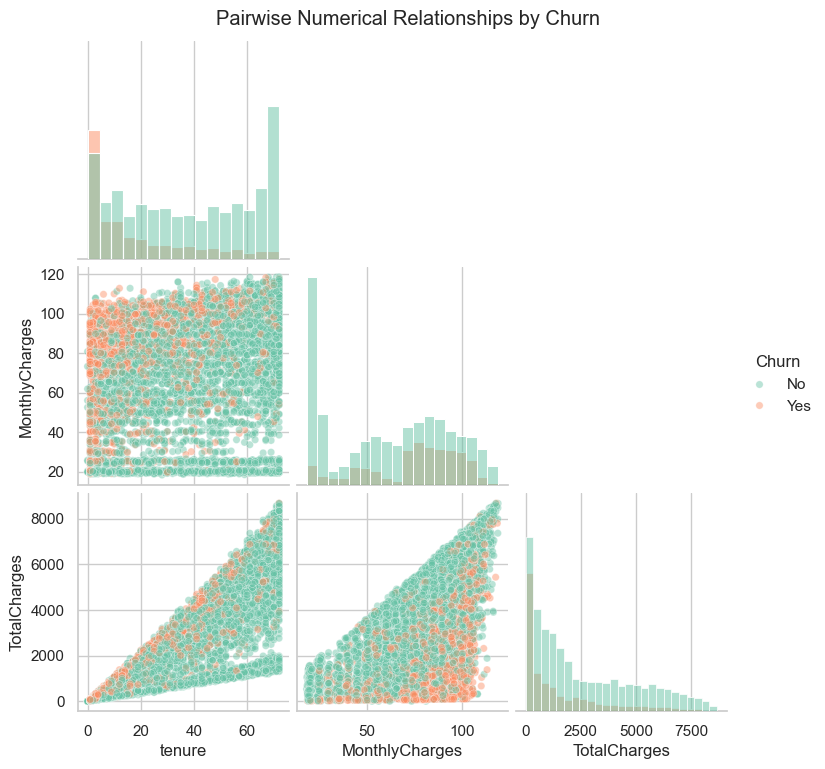

In [12]:
if len(numerical_columns) >= 2:
    pairplot_columns = numerical_columns + [target_column]
    pairplot_grid = sns.pairplot(
        df[pairplot_columns],
        hue=target_column,
        diag_kind="hist",
        corner=True,
        plot_kws={"alpha": 0.45, "s": 28},
        palette="Set2",
    )
    pairplot_grid.fig.suptitle("Pairwise Numerical Relationships by Churn", y=1.02)
    pairplot_grid.fig.savefig(
        NUMERICAL_RELATIONSHIPS_FIGURES_DIR / "numerical_pairplot.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Not enough numerical columns available for a pairplot.")


These scatter plots show that churn remains concentrated in the low-`tenure`, low-`TotalCharges` region even when numerical features are viewed jointly. The `tenure`-`TotalCharges` relationship is especially strong and confirms that customers who stay longer build more value, while the `tenure`-`MonthlyCharges` view shows much heavier class overlap, so price alone is not separating churn as clearly as lifecycle does. Overall, the numerical multivariate story is that early-stage customers remain the highest-risk group.


## Categorical Interaction Analysis

Important churn signals often emerge from combinations of service, contract, and payment choices rather than from a single category in isolation. This section compares selected categorical pairs using churn-rate tables, heatmaps, and Cramer's V so both churn risk and pair strength are visible.



Contract vs PaymentMethod churn rate (%)


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.13,32.78,53.73,31.58
One year,9.72,10.30,18.44,6.82
Two year,3.37,2.24,7.74,0.79



InternetService vs TechSupport churn rate (%)


TechSupport,No,No internet service,Yes
InternetService,,,
DSL,27.76,NaN,9.68
Fiber optic,49.37,NaN,22.63
No,NaN,7.4,NaN



InternetService vs OnlineSecurity churn rate (%)


OnlineSecurity,No,No internet service,Yes
InternetService,,,
DSL,27.96,NaN,9.49
Fiber optic,49.36,NaN,21.81
No,NaN,7.4,NaN


,feature_1,feature_2,cramers_v
2,InternetService,OnlineSecurity,0.7245
1,InternetService,TechSupport,0.7229
0,Contract,PaymentMethod,0.2667


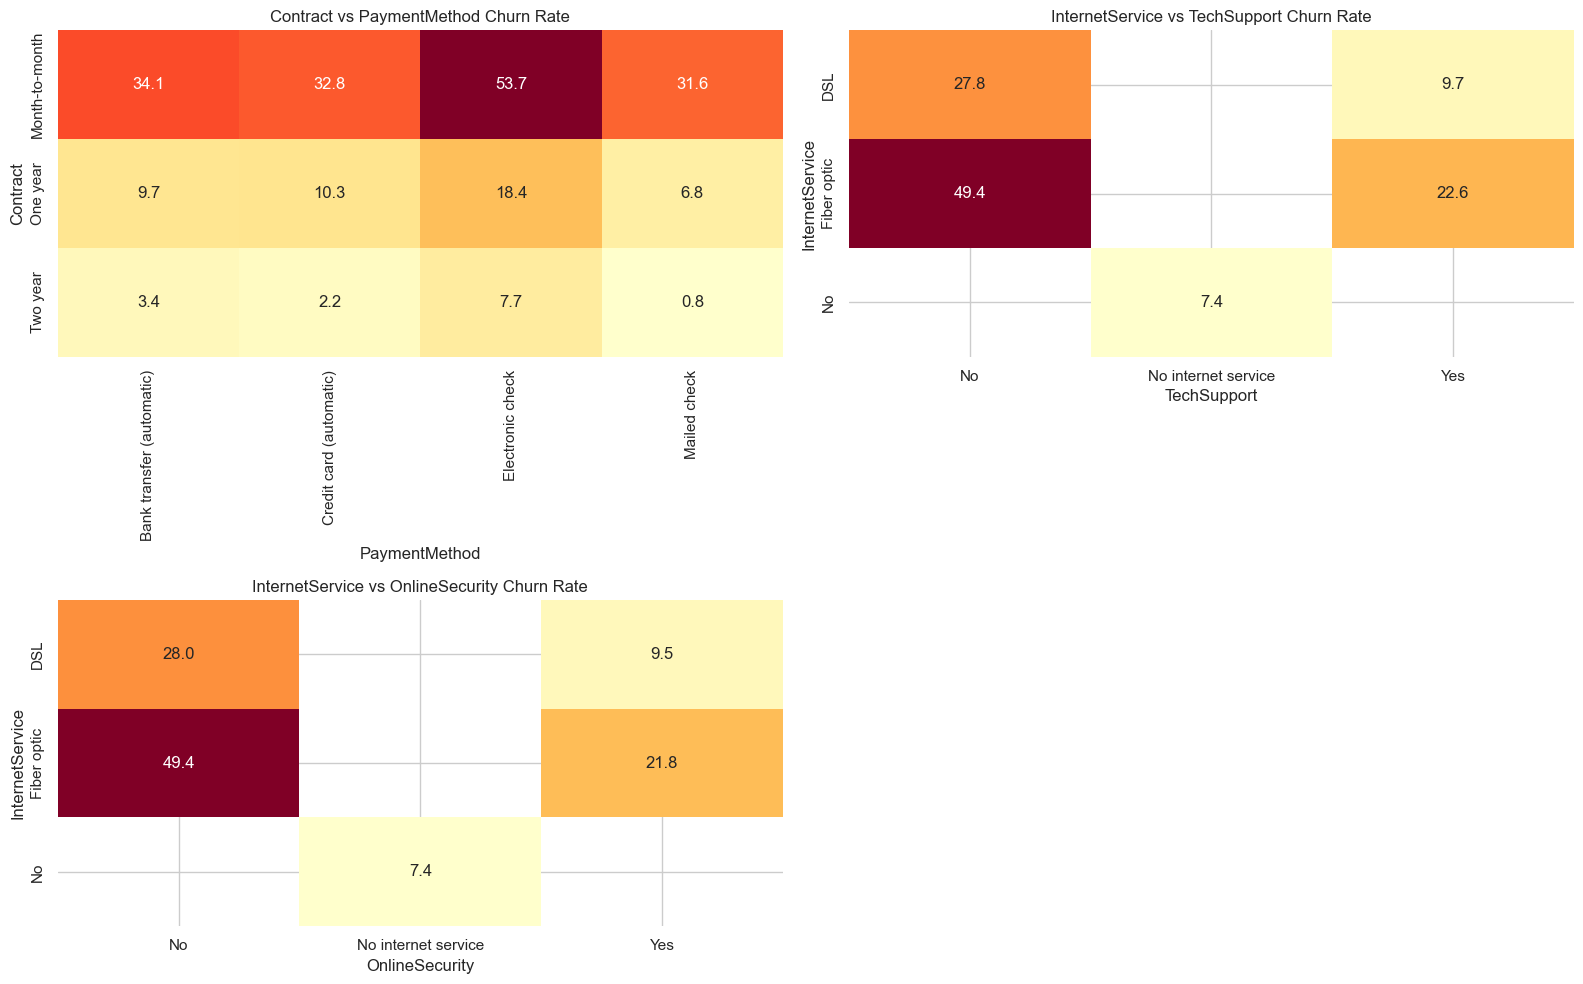

In [16]:
categorical_pairs = [
    pair for pair in [
        ("Contract", "PaymentMethod"),
        ("InternetService", "TechSupport"),
        ("InternetService", "OnlineSecurity"),
    ]
    if pair[0] in df.columns and pair[1] in df.columns
]

if categorical_pairs:
    def cramers_v(x, y):
        contingency_table = pd.crosstab(x, y)
        chi2 = chi2_contingency(contingency_table)[0]
        n_observations = contingency_table.to_numpy().sum()
        n_rows, n_columns = contingency_table.shape
        return round(np.sqrt(chi2 / (n_observations * (min(n_rows, n_columns) - 1))), 4)

    categorical_pair_strength_rows = []

    n_cols = 2
    n_rows = (len(categorical_pairs) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for index, (left_column, right_column) in enumerate(categorical_pairs):
        categorical_pair_strength_rows.append(
            {
                "feature_1": left_column,
                "feature_2": right_column,
                "cramers_v": cramers_v(df[left_column], df[right_column]),
            }
        )

        churn_rate_table = (
            df.groupby([left_column, right_column])[target_column]
            .apply(lambda values: values.eq("Yes").mean() * 100)
            .unstack()
            .round(2)
        )
        churn_rate_table.to_csv(
            CATEGORICAL_INTERACTIONS_TABLES_DIR
            / f"{left_column.lower()}_vs_{right_column.lower()}_churn_rate.csv"
        )

        print(f"\n{left_column} vs {right_column} churn rate (%)")
        display(churn_rate_table)

        ax = axes[index]
        sns.heatmap(
            churn_rate_table,
            annot=True,
            fmt=".1f",
            cmap="YlOrRd",
            cbar=False,
            ax=ax,
        )
        ax.set_title(f"{left_column} vs {right_column} Churn Rate")
        ax.set_xlabel(right_column)
        ax.set_ylabel(left_column)

    categorical_pair_strength_df = pd.DataFrame(categorical_pair_strength_rows).sort_values(
        "cramers_v", ascending=False
    )
    categorical_pair_strength_df.to_csv(
        CATEGORICAL_INTERACTIONS_TABLES_DIR / "categorical_pair_cramers_v.csv",
        index=False,
    )
    display(categorical_pair_strength_df)

    for index in range(len(categorical_pairs), len(axes)):
        fig.delaxes(axes[index])

    plt.tight_layout()
    plt.savefig(
        CATEGORICAL_INTERACTIONS_FIGURES_DIR / "categorical_pair_heatmaps.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Selected categorical interaction pairs are not available in the dataset.")


These categorical interaction tables reveal specific high-risk customer profiles. The most severe combination is `Month-to-month` plus `Electronic check`, where churn reaches `53.73%`, well above the other contract-payment combinations. Among internet users, `Fiber optic` customers without `TechSupport` churn at `49.37%`, and `Fiber optic` customers without `OnlineSecurity` churn at `49.36%`, which shows that service type becomes much riskier when protective add-ons are absent. The Cramer's V table shows that `InternetService` is very strongly associated with both `OnlineSecurity` (`0.7245`) and `TechSupport` (`0.7229`), so these service features are highly dependent and may carry overlapping information, while `Contract` and `PaymentMethod` are more loosely related at `0.2667` and may contribute more complementary signal together.


## Numerical and Categorical Interaction Analysis

Now compare key numerical features within important categorical groups while still splitting by churn. This helps reveal whether the same churn pattern behaves differently across contracts, services, or payment segments.


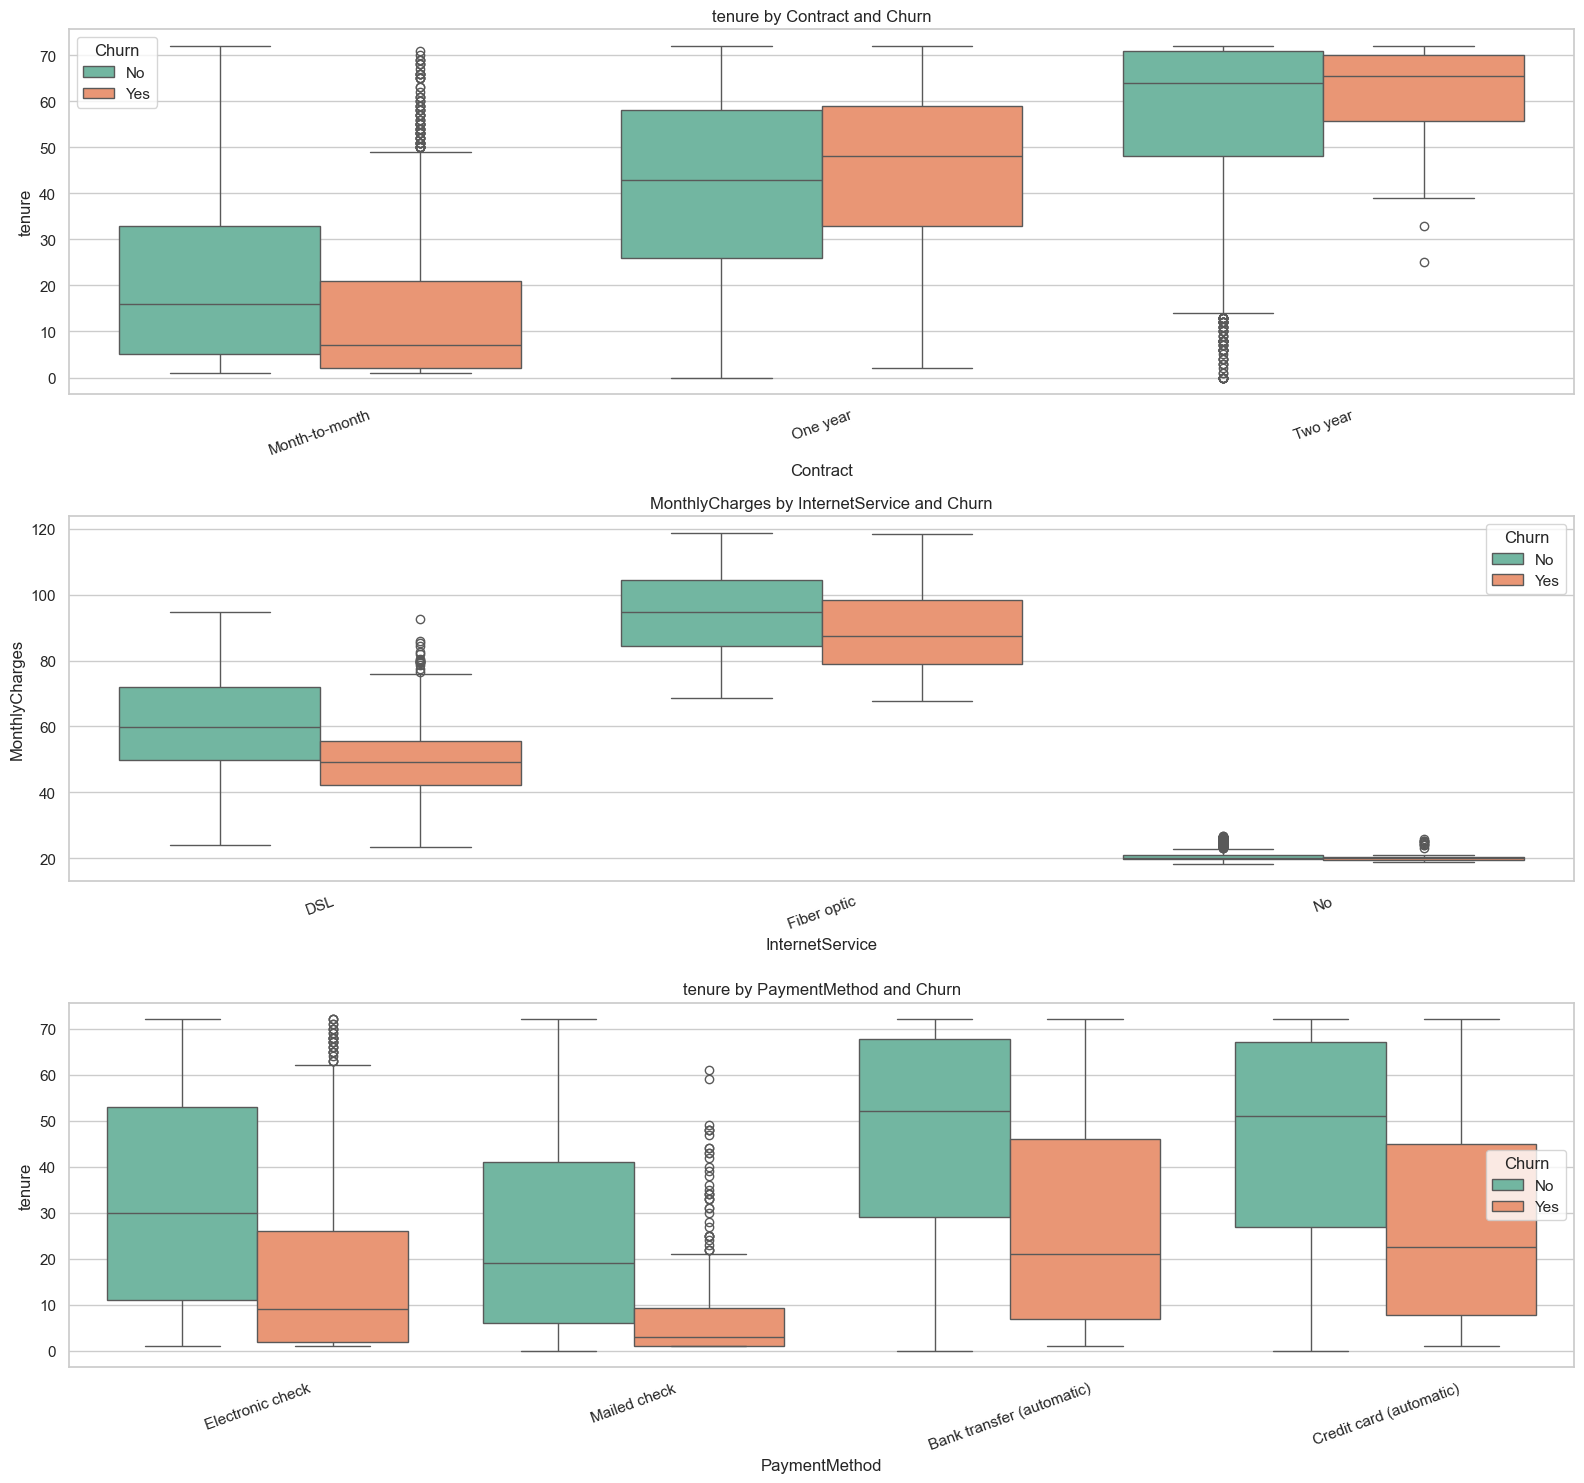

In [8]:
mixed_pairs = [
    pair for pair in [
        ("tenure", "Contract"),
        ("MonthlyCharges", "InternetService"),
        ("tenure", "PaymentMethod"),
    ]
    if pair[0] in df.columns and pair[1] in df.columns
]

if mixed_pairs:
    fig, axes = plt.subplots(len(mixed_pairs), 1, figsize=(16, 5 * len(mixed_pairs)))
    axes = np.atleast_1d(axes)

    for index, (numeric_column, category_column) in enumerate(mixed_pairs):
        ax = axes[index]
        sns.boxplot(
            data=df,
            x=category_column,
            y=numeric_column,
            hue=target_column,
            palette="Set2",
            ax=ax,
        )
        ax.set_title(f"{numeric_column} by {category_column} and {target_column}")
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.savefig(
        MIXED_INTERACTIONS_FIGURES_DIR / "numerical_categorical_boxplots.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Selected numerical and categorical interaction pairs are not available in the dataset.")


These mixed plots show that the core churn pattern survives inside important segments. Churned customers still have noticeably lower `tenure` within `Month-to-month`, `One year`, and the major payment-method groups, while `Fiber optic` customers continue to sit at the highest `MonthlyCharges` levels. That means the main churn story is not disappearing after segmentation: short customer history, weaker commitment, and higher-cost service profiles still move together.


## Multicollinearity Check

Before modeling, check whether some numerical predictors are too closely related. Strong collinearity can make coefficient-based models harder to interpret and may inflate variance estimates.


In [17]:
correlation_pairs = []

for left_index, left_column in enumerate(numerical_columns):
    for right_column in numerical_columns[left_index + 1 :]:
        correlation_pairs.append(
            {
                "feature_1": left_column,
                "feature_2": right_column,
                "correlation": round(float(df[left_column].corr(df[right_column])), 4),
                "abs_correlation": round(abs(float(df[left_column].corr(df[right_column]))), 4),
            }
        )

correlation_pairs_df = pd.DataFrame(correlation_pairs).sort_values(
    "abs_correlation", ascending=False
)
correlation_pairs_df.to_csv(
    NUMERICAL_RELATIONSHIPS_TABLES_DIR / "numerical_correlation_pairs.csv",
    index=False,
)

display(correlation_pairs_df)

vif_input = df[numerical_columns].dropna().astype(float).copy()
vif_rows = []

for column in vif_input.columns:
    y = vif_input[column].to_numpy()
    x_other = vif_input.drop(columns=[column]).to_numpy()
    x_design = np.column_stack([np.ones(len(x_other)), x_other])
    coefficients, _, _, _ = np.linalg.lstsq(x_design, y, rcond=None)
    y_hat = x_design @ coefficients
    ss_res = np.square(y - y_hat).sum()
    ss_tot = np.square(y - y.mean()).sum()
    r_squared = 1 - ss_res / ss_tot if ss_tot else 0.0
    vif_value = np.inf if np.isclose(1 - r_squared, 0.0) else 1 / (1 - r_squared)

    vif_rows.append(
        {
            "feature": column,
            "r_squared_against_others": round(float(r_squared), 4),
            "vif": round(float(vif_value), 4),
        }
    )

vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
vif_df.to_csv(
    NUMERICAL_RELATIONSHIPS_TABLES_DIR / "numerical_vif.csv",
    index=False,
)
display(vif_df)


,feature_1,feature_2,correlation,abs_correlation
1,tenure,TotalCharges,0.8262,0.8262
2,MonthlyCharges,TotalCharges,0.6512,0.6512
0,tenure,MonthlyCharges,0.2479,0.2479


,feature,r_squared_against_others,vif
2,TotalCharges,0.8949,9.5109
0,tenure,0.8287,5.8367
1,MonthlyCharges,0.6891,3.2167


In [23]:
vif_lookup = vif_df.set_index("feature")["vif"].to_dict()
tenure_vif = vif_lookup.get("tenure", float("nan"))
total_charges_vif = vif_lookup.get("TotalCharges", float("nan"))
monthly_charges_vif = vif_lookup.get("MonthlyCharges", float("nan"))

if tenure_vif >= 5 and total_charges_vif >= 5:
    vif_conclusion = (
        "These exceed the common threshold of 5, confirming moderate multicollinearity. "
        "Consider engineering a lifecycle ratio feature such as `TotalCharges / tenure` "
        "to reduce redundancy while preserving the monthly spend signal."
    )
else:
    vif_conclusion = (
        "These do not both exceed the common threshold of 5, so the overlap is present but less severe. "
        "The model can likely keep both features with careful interpretation or regularization."
    )

display(Markdown(
    f"The multicollinearity check confirms that `tenure` and `TotalCharges` are the closest numerical pair with correlation `0.8262`. "
    f"The VIF table above shows `tenure` at `{tenure_vif:.4f}`, `TotalCharges` at `{total_charges_vif:.4f}`, "
    f"and `MonthlyCharges` at `{monthly_charges_vif:.4f}`. {vif_conclusion}"
))


The multicollinearity check confirms that `tenure` and `TotalCharges` are the closest numerical pair with correlation `0.8262`. The VIF table above shows `tenure` at `5.8367`, `TotalCharges` at `9.5109`, and `MonthlyCharges` at `3.2167`. These exceed the common threshold of 5, confirming moderate multicollinearity. Consider engineering a lifecycle ratio feature such as `TotalCharges / tenure` to reduce redundancy while preserving the monthly spend signal.

## Interaction-Based Business Insights

- Churn remains concentrated among lower-tenure customers even after splitting by `Contract` and `PaymentMethod`, and the boxplots in the mixed-interaction section show that churned customers sit below non-churned customers across the major contract and payment groups.
- The clearest high-risk categorical profile is `Month-to-month` plus `Electronic check`, where churn reaches `53.73%`, making it the most exposed contract-payment combination in the notebook.
- `Fiber optic` customers become substantially riskier when support-oriented services are missing: churn is `49.37%` without `TechSupport` and `49.36%` without `OnlineSecurity`, versus `22.63%` and `21.81%` when those services are present.
- Taken together, the multivariate results identify the same vulnerable customer profile throughout the notebook: short-lifecycle customers with weaker commitment, higher-cost internet service, and lower support adoption.


## Modeling Implications

- Treat `tenure` and `TotalCharges` as partially overlapping lifecycle features because their correlation is `0.8262`; for linear models, consider regularization or engineered alternatives rather than reading both coefficients naively.
- Preserve `Contract`, `PaymentMethod`, `InternetService`, `TechSupport`, and `OnlineSecurity` because their combinations create some of the clearest churn-risk pockets in the notebook.
- Test explicit interaction terms such as `Contract x PaymentMethod` and `InternetService x TechSupport`, since the heatmaps show large churn jumps for combinations like `Month-to-month + Electronic check` and `Fiber optic + No TechSupport`.
- Tree-based models are likely to capture these non-additive patterns naturally, while linear models will need stronger feature engineering and careful encoding.


## Final Conclusion

This notebook shows that the churn story remains consistent after features are analyzed jointly. Numerically, `tenure` and `TotalCharges` move together strongly, with correlation `0.826`, and churn stays concentrated in the low-tenure, low-total-charge region. Categorically, the clearest high-risk profiles are `Month-to-month + Electronic check` (`53.73%` churn) and `Fiber optic` customers without `TechSupport` or `OnlineSecurity` (both about `49%` churn), which makes these interactions strong candidates for downstream modeling and targeted retention strategy.
